# Rock-Paper-Scissors Classification for Embedded Systems

## Project Overview
This project focuses on building a lightweight Convolutional Neural Network (CNN) to classify images of hand gestures (Rock, Paper, and Scissors). The final model is optimized using INT8 quantization to be deployed on resource-constrained hardware such as the ESP32.

## Methodology & Steps

1.  **Data Acquisition**: We utilized the `drgfreeman/rockpaperscissors` dataset from Kaggle, which contains high-quality images of the three classes.
2.  **Exploratory Data Analysis (EDA)**: Visualized sample images from each class to understand the input data format.
3.  **Data Preprocessing & Stratified Splitting**:
    *   Images were resized to **96x96** pixels.
    *   Converted to **Grayscale** to reduce memory footprint and computational complexity.
    *   Implemented a **Stratified Split (80/20)** using `scikit-learn` to ensure a balanced class distribution in both training and validation sets, resolving initial issues with class imbalance.
4.  **Model Architecture**: Designed a compact CNN with three Convolutional layers, MaxPooling, and Dropout to prevent overfitting while keeping the parameter count low.
5.  **Training**: The model was trained using the Adam optimizer and Sparse Categorical Crossentropy. Early Stopping was employed to restore the best weights and prevent unnecessary epochs.
6.  **Optimization (Quantization)**: Converted the Keras model to **TensorFlow Lite (TFLite)** format with **Full INT8 Quantization**. This step included generating a representative dataset to calibrate the dynamic ranges of the tensors.
7.  **Export**: The model was exported as a C++ byte array (`model_data.cc`) using `xxd` for direct integration into microcontroller firmware.

## Results

*   **Accuracy**: The model achieved high accuracy (>90%) on the validation set.
*   **Class Balance**: The Confusion Matrix confirms consistent performance across all three categories (Rock, Paper, and Scissors).
*   **Efficiency**: The final quantized model size is approximately **35 KB**, meeting the target requirement of 30-50 KB for deployment on ESP32 devices.

Dataset
https://www.kaggle.com/datasets/drgfreeman/rockpaperscissors?select=paper

In [58]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from collections import Counter

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


## **Load Dataset**

In [14]:
import kagglehub

path = kagglehub.dataset_download("drgfreeman/rockpaperscissors")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'rockpaperscissors' dataset.
Path to dataset files: /kaggle/input/rockpaperscissors


In [15]:
!ls /kaggle/input/rockpaperscissors

paper  README_rpc-cv-images.txt  rock  rps-cv-images  scissors


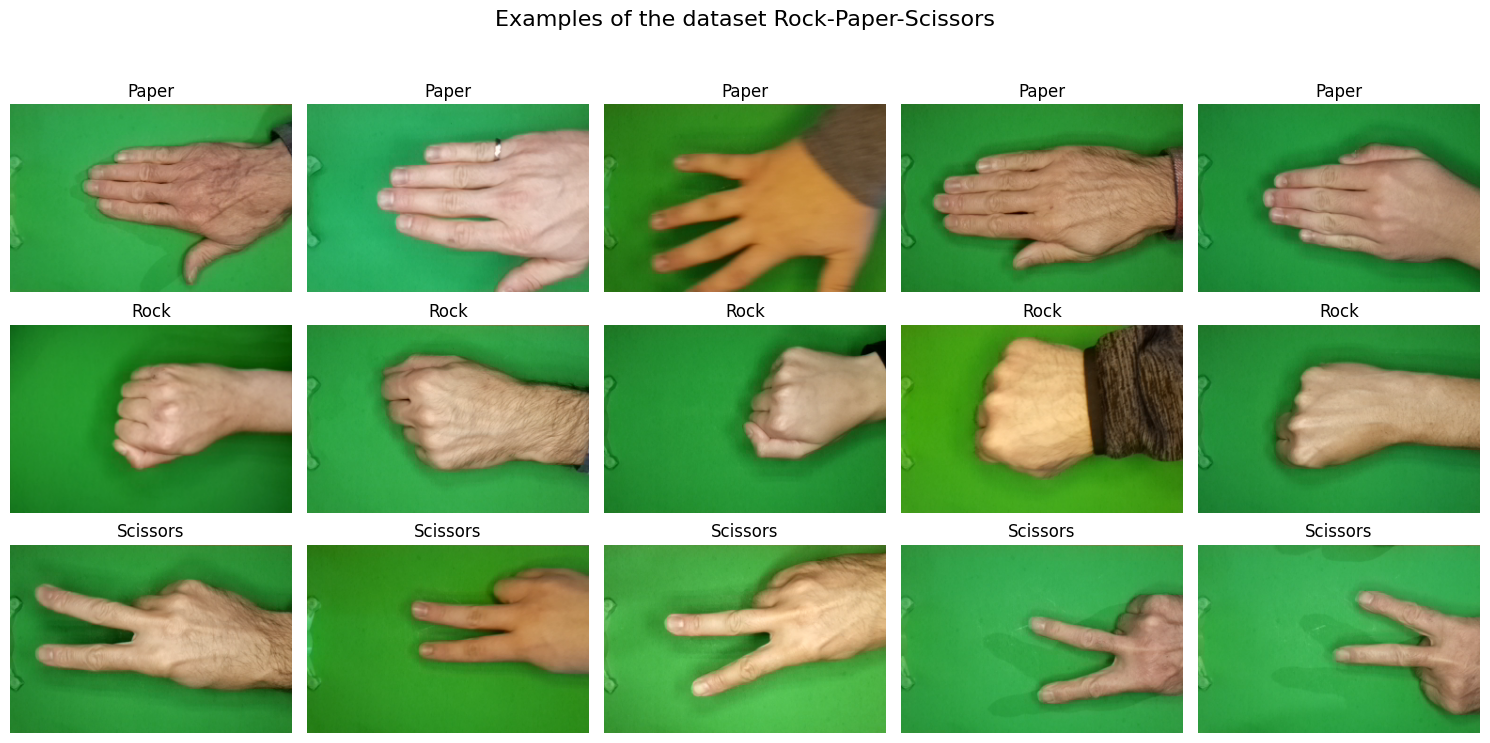

In [59]:
import matplotlib.pyplot as plt
import os
import matplotlib.image as mpimg
import random

path = '/kaggle/input/rockpaperscissors'

all_items = os.listdir(path)
class_names = [item for item in all_items if os.path.isdir(os.path.join(path, item)) and item in ['rock', 'paper', 'scissors']]
class_names.sort()

plt.figure(figsize=(15, 8))
num_examples_per_class = 5

for i, class_name in enumerate(class_names):
    class_dir = os.path.join(path, class_name)
    images_in_class = [f for f in os.listdir(class_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]

    selected_images = random.sample(images_in_class, min(num_examples_per_class, len(images_in_class)))

    for j, img_name in enumerate(selected_images):
        img_path = os.path.join(class_dir, img_name)
        img = mpimg.imread(img_path)

        plt.subplot(len(class_names), num_examples_per_class, i * num_examples_per_class + j + 1)
        plt.imshow(img)
        plt.title(f"{class_name.capitalize()}")
        plt.axis('off')

plt.suptitle("Examples of the dataset Rock-Paper-Scissors", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## **Split Dataset**

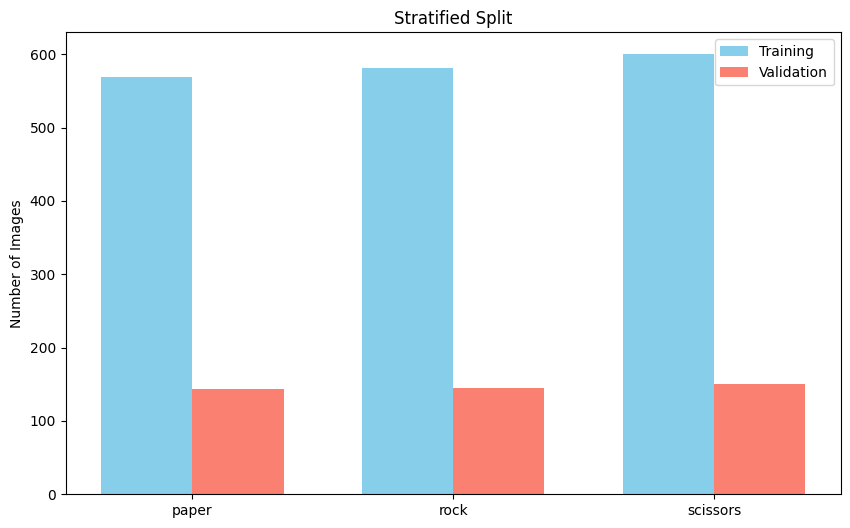

Training: {2: 600, 0: 569, 1: 581}
Validation: {2: 150, 1: 145, 0: 143}


In [60]:
IMG_SIZE = 96
BATCH_SIZE = 32
class_names = ['paper', 'rock', 'scissors']
path = '/kaggle/input/rockpaperscissors'

all_filepaths = []
all_labels = []

for i, class_name in enumerate(class_names):
    class_dir = os.path.join(path, class_name)
    files = [os.path.join(class_dir, f) for f in os.listdir(class_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]
    all_filepaths.extend(files)
    all_labels.extend([i] * len(files))

# split
train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_filepaths, all_labels, test_size=0.2, stratify=all_labels, random_state=123
)

def load_and_preprocess(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.image.rgb_to_grayscale(image)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# create datasets
train_ds_preprocessed = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))\
    .map(load_and_preprocess).shuffle(1000).batch(BATCH_SIZE).prefetch(buffer_size=tf.data.AUTOTUNE)

val_ds_preprocessed = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))\
    .map(load_and_preprocess).batch(BATCH_SIZE).prefetch(buffer_size=tf.data.AUTOTUNE)

# visualization
train_counts = Counter(train_labels)
val_counts = Counter(val_labels)

x = np.arange(len(class_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, [train_counts[i] for i in range(3)], width, label='Training', color='skyblue')
ax.bar(x + width/2, [val_counts[i] for i in range(3)], width, label='Validation', color='salmon')

ax.set_ylabel('Number of Images')
ax.set_title('Stratified Split')
ax.set_xticks(x)
ax.set_xticklabels(class_names)
ax.legend()

plt.show()

print(f"Training: {dict(train_counts)}")
print(f"Validation: {dict(val_counts)}")

## **Create Model**

In [61]:
model = tf.keras.models.Sequential([
    tf.keras.layers.InputLayer(input_shape=(IMG_SIZE, IMG_SIZE, 1)),

    tf.keras.layers.Conv2D(8, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(16, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # This block reduces the weights
    tf.keras.layers.Conv2D(16, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(3, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_35 (Conv2D)              │ (None, 94, 94, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 47, 47, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 45, 45, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_36 (MaxPooling2D) │ (None, 22, 22, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 20, 20, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_37 (MaxPooling2D) │ (None, 10, 10, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 16)             │        25,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,235 (114.20 KB)

 Trainable params: 29,235 (114.20 KB)

 Non-trainable params: 0 (0.00 B)

In [62]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [63]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_ds_preprocessed,
    epochs=20,
    validation_data=val_ds_preprocessed,
    callbacks=[early_stopping]
)


Epoch 1/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - accuracy: 0.4811 - loss: 1.0449 - val_accuracy: 0.7557 - val_loss: 0.8954
Epoch 2/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7211 - loss: 0.7091 - val_accuracy: 0.8539 - val_loss: 0.4849
Epoch 3/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8194 - loss: 0.4510 - val_accuracy: 0.8242 - val_loss: 0.4198
Epoch 4/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8726 - loss: 0.3516 - val_accuracy: 0.9087 - val_loss: 0.2811
Epoch 5/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8846 - loss: 0.2926 - val_accuracy: 0.8973 - val_loss: 0.2935
Epoch 6/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9177 - loss: 0.2465 - val_accuracy: 0.9452 - val_loss: 0.2076
Epoch 7/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9166 - loss: 0.2351 - val_accuracy: 0.9201 - val_loss: 0.2235
Epoch 8/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9251 - loss: 0.2071 - val_accuracy: 0.9361 - val_lo

## **Confusion Matrix**

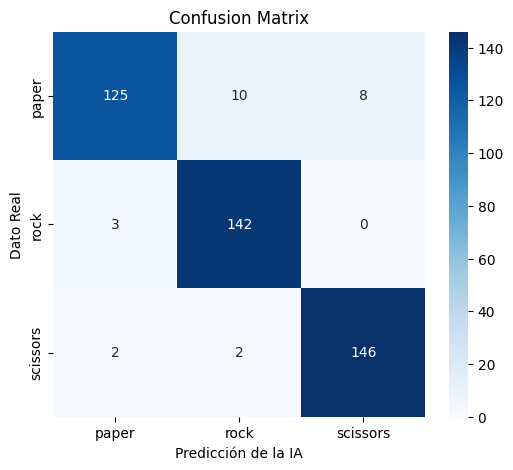

In [68]:
import collections

y_true = []
y_pred = []

for images, labels in val_ds_preprocessed:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicción de la IA')
plt.ylabel('Dato Real')
plt.title('Confusion Matrix')
plt.show()

## **Quantization to INT8**

In [66]:
def representative_data_gen():
    for input_value, _ in train_ds_preprocessed.take(100):
        yield [input_value]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_model = converter.convert()

with open('model.tflite', 'wb') as f:
    f.write(tflite_model)
print(f"Model Size TFLite: {len(tflite_model) / 1024:.2f} KB (MUST be ~30-50 KB)")

Saved artifact at '/tmp/tmph5yubvnn'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 96, 96, 1), dtype=tf.float32, name='keras_tensor_135')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  137789800479056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137789800480592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137789800480016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137789800471376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137789800479632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137789800480400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137789800480208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137789800478864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137789198418192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137789198418768: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Model Size TFLite: 35.30 KB (MUST be ~30-50 KB)


## **Export Model**

In [67]:
!apt-get update && apt-get install -y xxd
!xxd -i model.tflite > model_data.cc
!sed -i 's/unsigned char/const unsigned char/g' model_data.cc
!sed -i 's/model_tflite/g_model/g' model_data.cc

print("Ready")

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [95.6 kB]
Get:6 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,945 kB]
Hit:7 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:8 http://security.ubuntu.com/ubuntu jammy-security/multiverse amd64 Packages [77.8 kB]
Get:9 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7,070 kB]
Get:10 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,295 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:13 https://ppa.launchpadcontent.net/deadsnakes/p